# NBA Player Statistics EDA

This project looks at player stats from the 2021-2022 NBA regular season.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Dataset

In [4]:
data = pd.read_csv("2021-2022 NBA Player Stats - Regular.csv", sep=";", encoding="latin1")
data.head()

,Rk,Player,Pos,Age,Tm,G,GS,MP,FG,FGA,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,1,Precious Achiuwa,C,22,TOR,73,28,23.6,3.6,8.3,...,0.595,2.0,4.5,6.5,1.1,0.5,0.6,1.2,2.1,9.1
1,2,Steven Adams,C,28,MEM,76,75,26.3,2.8,5.1,...,0.543,4.6,5.4,10.0,3.4,0.9,0.8,1.5,2.0,6.9
2,3,Bam Adebayo,C,24,MIA,56,56,32.6,7.3,13.0,...,0.753,2.4,7.6,10.1,3.4,1.4,0.8,2.6,3.1,19.1
3,4,Santi Aldama,PF,21,MEM,32,0,11.3,1.7,4.1,...,0.625,1.0,1.7,2.7,0.7,0.2,0.3,0.5,1.1,4.1
4,5,LaMarcus Aldridge,C,36,BRK,47,12,22.3,5.4,9.7,...,0.873,1.6,3.9,5.5,0.9,0.3,1.0,0.9,1.7,12.9


## Basic Data Exploration

In [5]:
print("Shape of the dataset:")
print(data.shape)

print("\nColumns:")
print(data.columns)

print("\nData types:")
print(data.dtypes)

print("\nMissing values:")
print(data.isnull().sum())

print("\nBasic statistics:")
print(data.describe())

Shape of the dataset:
(812, 30)

Columns:
Index(['Rk', 'Player', 'Pos', 'Age', 'Tm', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%',
       '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%',
       'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS'],
      dtype='object')

Data types:
Rk          int64
Player     object
Pos        object
Age         int64
Tm         object
G           int64
GS          int64
MP        float64
FG        float64
FGA       float64
FG%       float64
3P        float64
3PA       float64
3P%       float64
2P        float64
2PA       float64
2P%       float64
eFG%      float64
FT        float64
FTA       float64
FT%       float64
ORB       float64
DRB       float64
TRB       float64
AST       float64
STL       float64
BLK       float64
TOV       float64
PF        float64
PTS       float64
dtype: object

Missing values:
Rk        0
Player    0
Pos       0
Age       0
Tm        0
G         0
GS        0
MP        0
FG        0
FGA       0
FG%    

In [6]:
print("Players by position:")
print(data["Pos"].value_counts())

print("\nPlayers by team:")
print(data["Tm"].value_counts())

Players by position:
Pos
SG       199
SF       158
PG       155
PF       152
C        130
SG-SF      5
SF-SG      5
SG-PG      4
C-PF       2
PG-SG      1
PF-SF      1
Name: count, dtype: int64

Players by team:
Tm
TOT    97
WAS    29
MIL    29
IND    28
BOS    28
DET    27
DAL    27
POR    27
CLE    26
SAC    26
OKC    26
LAL    25
ATL    24
UTA    24
BRK    24
SAS    24
PHO    23
PHI    23
LAC    23
TOR    23
MEM    23
NYK    23
NOP    22
DEN    22
ORL    22
MIA    22
CHI    22
HOU    19
CHO    19
MIN    18
GSW    17
Name: count, dtype: int64


## Data Cleaning

In [7]:
data = data.drop_duplicates()

data["Player"] = data["Player"].str.strip()
data["Pos"] = data["Pos"].str.strip()
data["Tm"] = data["Tm"].str.strip()

num_cols = ["Age", "G", "GS", "MP", "PTS", "TRB", "AST", "STL", "BLK", "FG%", "3P%", "FT%"]

for col in num_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")

data["FG%"] = data["FG%"].fillna(0)
data["3P%"] = data["3P%"].fillna(0)
data["FT%"] = data["FT%"].fillna(0)

data.head()

,Rk,Player,Pos,Age,Tm,G,GS,MP,FG,FGA,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,1,Precious Achiuwa,C,22,TOR,73,28,23.6,3.6,8.3,...,0.595,2.0,4.5,6.5,1.1,0.5,0.6,1.2,2.1,9.1
1,2,Steven Adams,C,28,MEM,76,75,26.3,2.8,5.1,...,0.543,4.6,5.4,10.0,3.4,0.9,0.8,1.5,2.0,6.9
2,3,Bam Adebayo,C,24,MIA,56,56,32.6,7.3,13.0,...,0.753,2.4,7.6,10.1,3.4,1.4,0.8,2.6,3.1,19.1
3,4,Santi Aldama,PF,21,MEM,32,0,11.3,1.7,4.1,...,0.625,1.0,1.7,2.7,0.7,0.2,0.3,0.5,1.1,4.1
4,5,LaMarcus Aldridge,C,36,BRK,47,12,22.3,5.4,9.7,...,0.873,1.6,3.9,5.5,0.9,0.3,1.0,0.9,1.7,12.9


## Feature Engineering

In [8]:
data["PointsPerMinute"] = data["PTS"] / data["MP"]
data["AssistsPerGame"] = data["AST"] / data["G"]
data["ReboundsPerGame"] = data["TRB"] / data["G"]

data[["Player", "PointsPerMinute", "AssistsPerGame", "ReboundsPerGame"]].head()

,Player,PointsPerMinute,AssistsPerGame,ReboundsPerGame
0,Precious Achiuwa,0.385593,0.015068,0.089041
1,Steven Adams,0.262357,0.044737,0.131579
2,Bam Adebayo,0.585890,0.060714,0.180357
3,Santi Aldama,0.362832,0.021875,0.084375
4,LaMarcus Aldridge,0.578475,0.019149,0.117021


## Visualizations

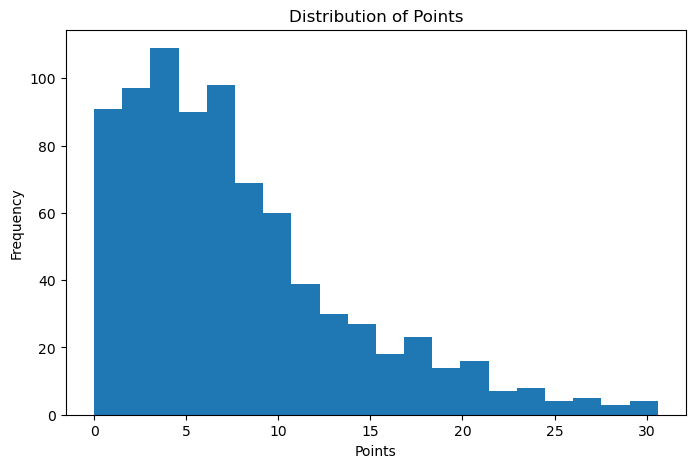

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(data["PTS"], bins=20)
plt.title("Distribution of Points")
plt.xlabel("Points")
plt.ylabel("Frequency")
plt.show()

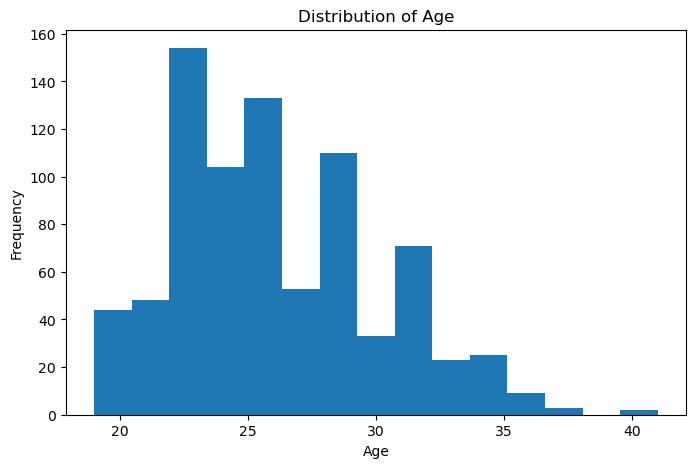

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(data["Age"], bins=15)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

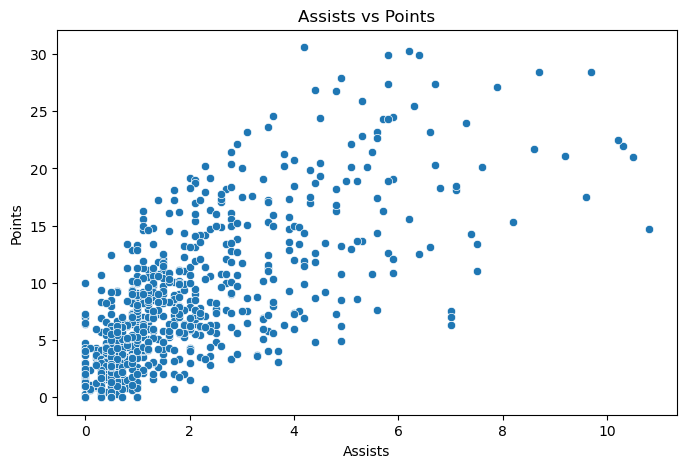

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x="AST", y="PTS")
plt.title("Assists vs Points")
plt.xlabel("Assists")
plt.ylabel("Points")
plt.show()

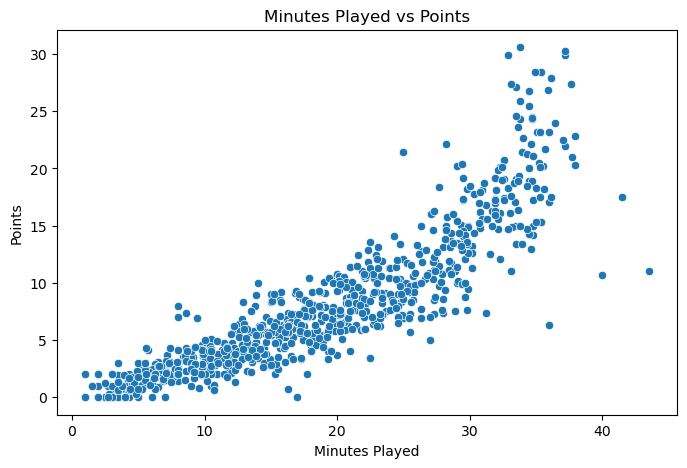

In [12]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x="MP", y="PTS")
plt.title("Minutes Played vs Points")
plt.xlabel("Minutes Played")
plt.ylabel("Points")
plt.show()

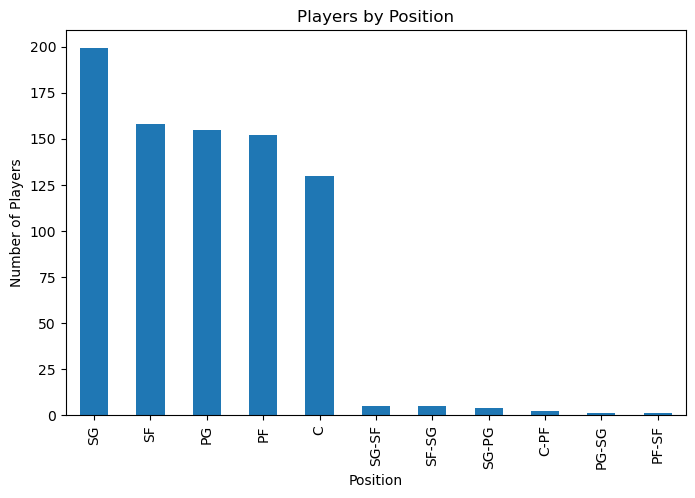

In [13]:
plt.figure(figsize=(8, 5))
data["Pos"].value_counts().plot(kind="bar")
plt.title("Players by Position")
plt.xlabel("Position")
plt.ylabel("Number of Players")
plt.show()

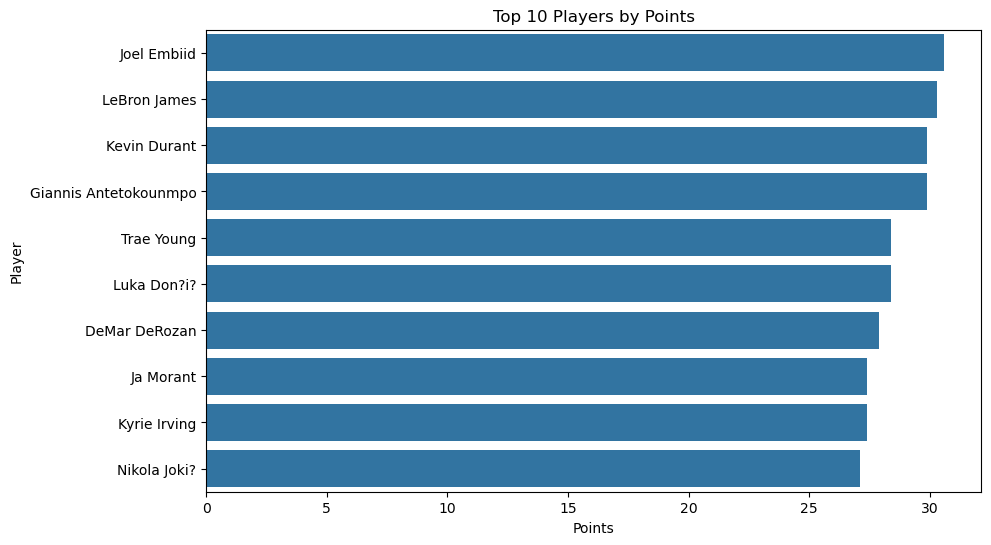

In [14]:
top10 = data.sort_values(by="PTS", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top10, x="PTS", y="Player")
plt.title("Top 10 Players by Points")
plt.xlabel("Points")
plt.ylabel("Player")
plt.show()

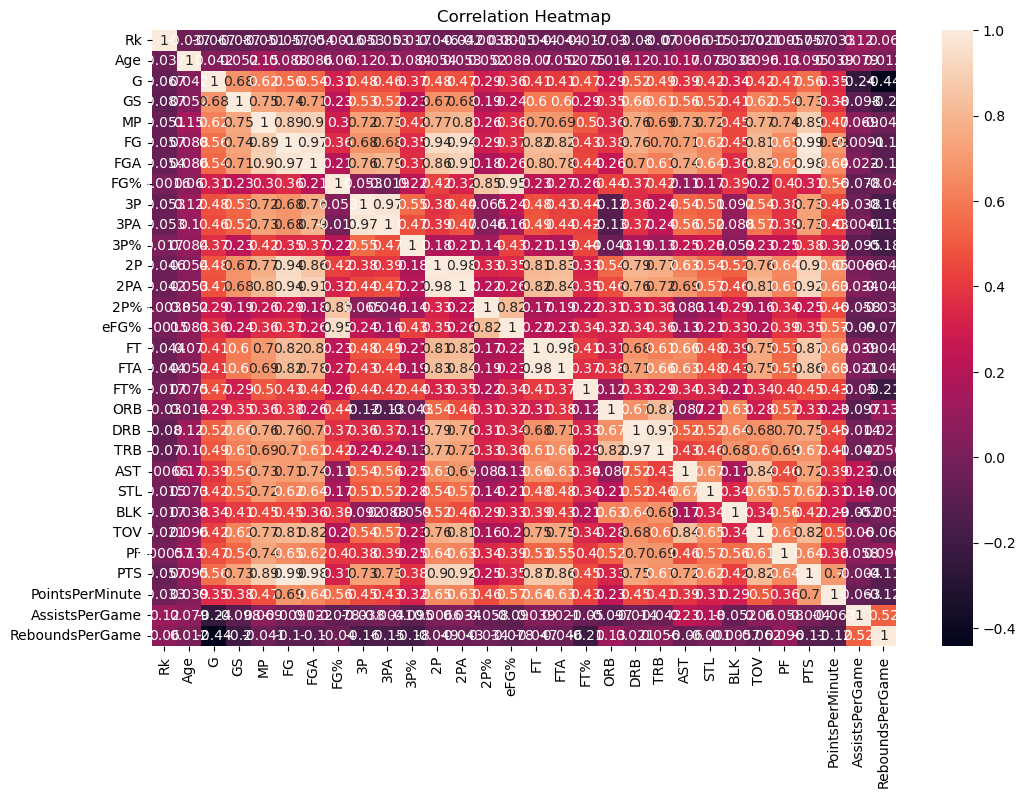

In [15]:
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

## Conclusions

In [16]:
print("The most common position is", data["Pos"].value_counts().idxmax())
print("The team with the most players is", data["Tm"].value_counts().idxmax())
print("The highest scorer is", data.loc[data["PTS"].idxmax(), "Player"])
print("The player with the highest points per minute is", data.loc[data["PointsPerMinute"].idxmax(), "Player"])
print("Overall, minutes played and points seem to have a positive relationship.")

The most common position is SG
The team with the most players is TOT
The highest scorer is Joel Embiid
The player with the highest points per minute is Ahmad Caver
Overall, minutes played and points seem to have a positive relationship.
